

CLASIFICACIÓN DE PLANTAS MEDICINALES DE BOLIVIA CON YOLO
Estudiante: Nicole Lozada León
Materia: Inteligencia Artificial
SIN TRANSFER LEARNING - Entrenamiento desde cero




In [ ]:

# =============================================================================
# CELDA 1: CONFIGURACIÓN INICIAL Y VERIFICACIÓN DE GPU
# =============================================================================
# Tiempo estimado: 30 segundos

import torch
import os
from datetime import datetime

# Verificar GPU disponible (CRUCIAL para entrenamiento rápido)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"✅ GPU disponible: {gpu_name}")
    print(f"   Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️  GPU NO disponible - El entrenamiento será LENTO")
    print("   Ve a: Runtime > Change runtime type > Hardware accelerator > GPU")

print(f"\n📅 Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)

✅ GPU disponible: Tesla T4
   Memoria GPU: 15.83 GB

📅 Fecha de ejecución: 2025-11-21 10:37:49


In [ ]:
# =============================================================================
# CELDA 2: MONTAR GOOGLE DRIVE
# =============================================================================
# Tiempo estimado: 10 segundos
# Aquí guardaremos los modelos entrenados

from google.colab import drive
drive.mount('/content/drive')

# Crear carpeta del proyecto en Drive
PROJECT_DIR = '/content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/modelos', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/resultados', exist_ok=True)

print(f"✅ Drive montado correctamente")
print(f"📁 Carpeta del proyecto: {PROJECT_DIR}")

Mounted at /content/drive
✅ Drive montado correctamente
📁 Carpeta del proyecto: /content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia


In [ ]:

# =============================================================================
# CELDA 3: INSTALAR DEPENDENCIAS
# =============================================================================
# Tiempo estimado: 1-2 minutos

print("📦 Instalando Ultralytics (YOLO)...")
!pip install -q ultralytics roboflow

# Verificar instalación
from ultralytics import YOLO
import roboflow

print("✅ Ultralytics instalado correctamente")
print(f"   Versión: {ultralytics.__version__}")

📦 Instalando Ultralytics (YOLO)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 129.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics instalado correctamente


NameError: name 'ultralytics' is not defined

In [ ]:
# =============================================================================
# CELDA 4: IMPORTAR Y PREPARAR DATASET DESDE ROBOFLOW
# =============================================================================
# Tiempo estimado: 2-5 minutos (depende del tamaño del dataset)

"""
PASOS PREVIOS EN ROBOFLOW (haz esto ANTES de ejecutar esta celda):

1. Ve a https://roboflow.com y crea una cuenta gratuita
2. Crea un nuevo proyecto: "Plantas Medicinales Bolivia"
3. Sube tus 2100 imágenes (700 de cada clase)
4. Anota cada planta:
   - Dibuja bounding boxes alrededor de CADA planta visible
   - Etiqueta: "romero", "menta", "eucalipto"
   - Tip: Usa atajos de teclado para ir más rápido
5. Ve a "Generate" > "Preprocessing":
   ✅ Auto-Orient: ON
   ✅ Resize: 640x640 (Stretch to)
6. Ve a "Augmentations" (IMPORTANTE para imágenes desde arriba):
   ✅ Flip: Horizontal + Vertical
   ✅ Rotation: Between -15° and +15°
   ✅ Brightness: Between -15% and +15%
   ✅ Exposure: Between -15% and +15%
   ✅ Blur: Up to 1px
   Esto te dará ~6300 imágenes (3x más datos)
7. Genera el dataset con estas configuraciones
8. Ve a "Export" > Formato: "YOLOv8" > "Show download code"
9. Copia tu API key y el código que aparece
"""

# Pega aquí tu código de Roboflow (reemplaza estos valores):
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ScqTCR3IDHPN76fZUCyi")
project = rf.workspace("nlinlin").project("plantsdetection-ddgie")
version = project.version(2)
dataset = version.download("yolov8")



print(f"✅ Dataset descargado en: {dataset.location}")
print(f"📊 Estructura:")
print(f"   - Train: {len(os.listdir(f'{dataset.location}/train/images'))} imágenes")
print(f"   - Valid: {len(os.listdir(f'{dataset.location}/valid/images'))} imágenes")
print(f"   - Test: {len(os.listdir(f'{dataset.location}/test/images'))} imágenes")

# Guardar ruta del dataset
DATASET_YAML = f"{dataset.location}/data.yaml"


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to plantsDetection-2 in yolov8:: 100%|██████████| 7524/7524 [00:05<00:00, 1434.34it/s]


✅ Dataset descargado en: /content/plantsDetection-2
📊 Estructura:
   - Train: 3468 imágenes
   - Valid: 142 imágenes
   - Test: 146 imágenes


📋 Configuración del dataset:
   Clases: ['eucalipto', 'menta', 'romero']
   Número de clases: 3
   Path train: ../train/images
   Path val: ../valid/images


Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.


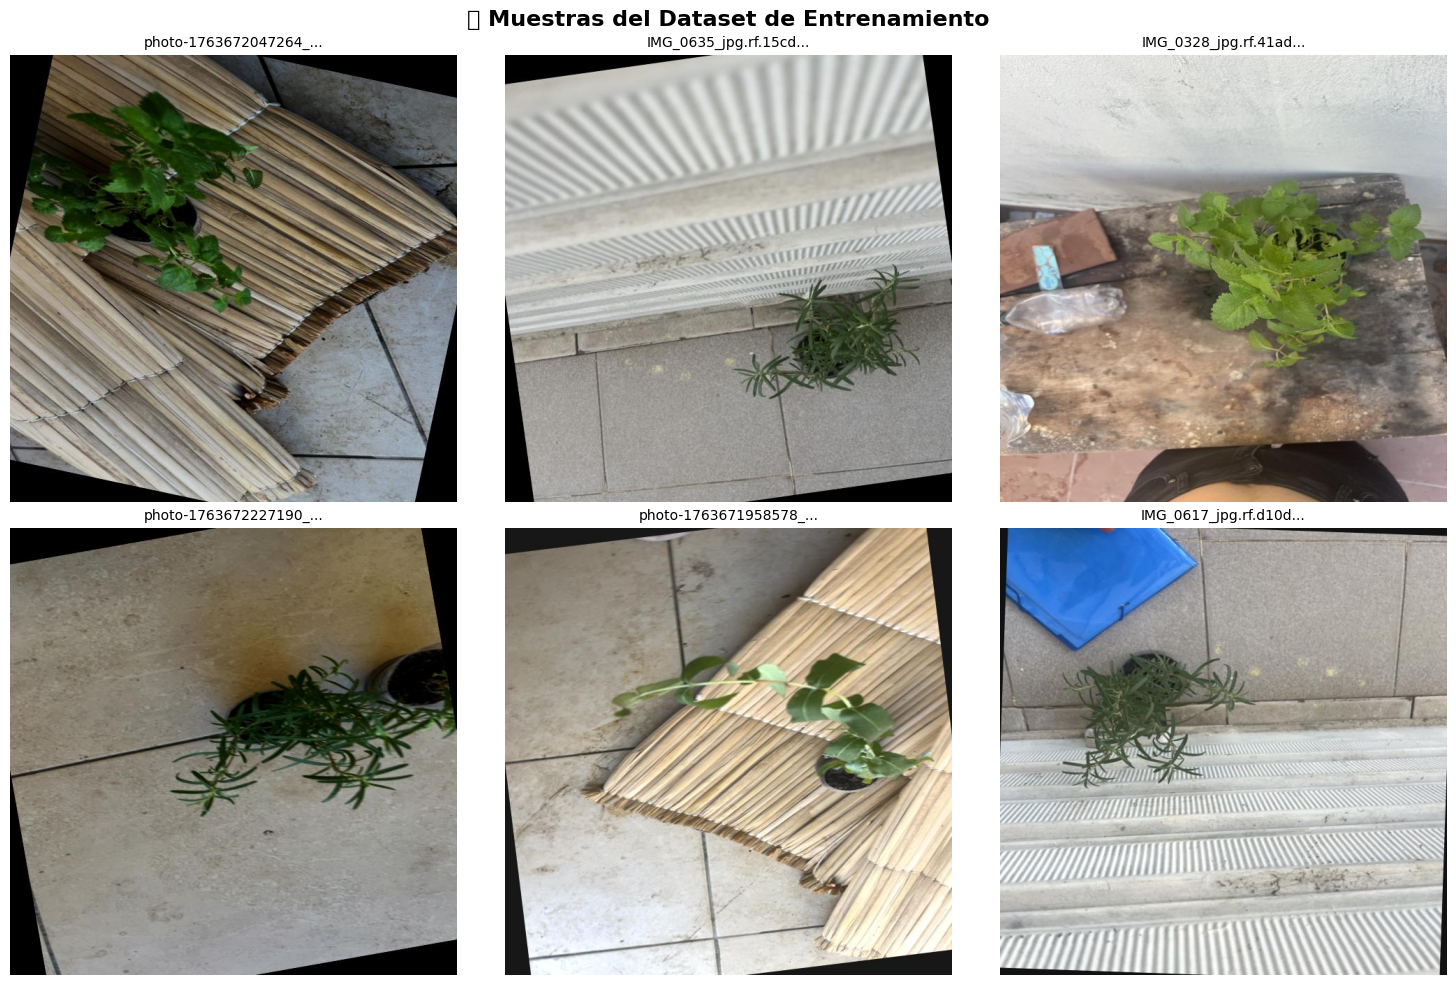

✅ Gráfico guardado en: /content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/resultados/muestras_dataset.png


In [ ]:
# =============================================================================
# CELDA 5: INSPECCIONAR EL DATASET
# =============================================================================
# Tiempo estimado: 10 segundos

import yaml
from PIL import Image
import matplotlib.pyplot as plt
import random

# Leer configuración del dataset
with open(DATASET_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

print("📋 Configuración del dataset:")
print(f"   Clases: {data_config['names']}")
print(f"   Número de clases: {data_config['nc']}")
print(f"   Path train: {data_config['train']}")
print(f"   Path val: {data_config['val']}")

# Mostrar algunas imágenes de ejemplo
train_images = os.listdir(f"{dataset.location}/train/images")
sample_images = random.sample(train_images, min(6, len(train_images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('🌿 Muestras del Dataset de Entrenamiento', fontsize=16, fontweight='bold')

for idx, img_name in enumerate(sample_images):
    img_path = f"{dataset.location}/train/images/{img_name}"
    img = Image.open(img_path)

    ax = axes[idx // 3, idx % 3]
    ax.imshow(img)
    ax.set_title(f"{img_name[:20]}...", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/resultados/muestras_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Gráfico guardado en: {PROJECT_DIR}/resultados/muestras_dataset.png")



In [ ]:
# =============================================================================
# CELDA 6: CONFIGURAR HIPERPARÁMETROS DE ENTRENAMIENTO
# =============================================================================
# Tiempo estimado: 5 segundos

"""
HIPERPARÁMETROS EXPLICADOS:

- epochs: Número de vueltas completas al dataset
  * Más épocas = mejor aprendizaje, pero más tiempo
  * YOLO usa Early Stopping (para automáticamente si no mejora)

- imgsz: Tamaño de imagen (640x640 es estándar para YOLO)

- batch: Imágenes procesadas simultáneamente
  * Mayor = más rápido, pero necesita más memoria GPU
  * Si da error de memoria, reduce a 8 o 4

- patience: Épocas sin mejora antes de parar

- pretrained: False = SIN TRANSFER LEARNING (requisito de tu proyecto)
"""

# Configuración de entrenamiento
TRAINING_CONFIG = {
    'epochs': 100,           # Máximo de épocas (parará antes si converge)
    'imgsz': 640,            # Tamaño de imagen
    'batch': 16,             # Ajusta según tu GPU (16 para T4, 8 para K80)
    'patience': 50,          # Early stopping
    'save_period': 10,       # Guardar checkpoint cada 10 épocas
    'workers': 8,            # Threads para cargar datos
    'pretrained': False,     # ⚠️ CRÍTICO: Entrenar desde cero
    'optimizer': 'SGD',      # Stochastic Gradient Descent
    'lr0': 0.01,             # Learning rate inicial
    'momentum': 0.937,       # Momentum
    'weight_decay': 0.0005,  # Regularización
    'cos_lr': True,          # Cosine learning rate scheduler
}

print("⚙️  Configuración de entrenamiento:")
for key, value in TRAINING_CONFIG.items():
    print(f"   {key}: {value}")

# Nombre único para esta ejecución
RUN_NAME = f"plantas_bolivia_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
print(f"\n📝 Nombre de la ejecución: {RUN_NAME}")

⚙️  Configuración de entrenamiento:
   epochs: 100
   imgsz: 640
   batch: 16
   patience: 50
   save_period: 10
   workers: 8
   pretrained: False
   optimizer: SGD
   lr0: 0.01
   momentum: 0.937
   weight_decay: 0.0005
   cos_lr: True

📝 Nombre de la ejecución: plantas_bolivia_20251121_110516


In [ ]:
# =============================================================================
# CELDA 7: CREAR MODELO YOLO DESDE CERO
# =============================================================================
# Tiempo estimado: 10 segundos

"""
ARQUITECTURAS YOLO DISPONIBLES:

- yolov8n.yaml: Nano (más rápido, menos preciso) - 3.2M parámetros
- yolov8s.yaml: Small (balanceado) - 11.2M parámetros ✅ RECOMENDADO
- yolov8m.yaml: Medium (más preciso, más lento) - 25.9M parámetros
- yolov8l.yaml: Large (muy preciso, muy lento) - 43.7M parámetros
- yolov8x.yaml: Extra Large (máxima precisión) - 68.2M parámetros

Para tu caso (700 imágenes por clase), yolov8s es ideal.
"""

# Crear modelo desde cero (SIN pesos pre-entrenados)
model = YOLO('yolov8s.yaml')  # Arquitectura Small

print("✅ Modelo YOLO creado desde cero")
print(f"   Arquitectura: YOLOv8 Small")
print(f"   Parámetros: ~11.2M")
print(f"   Sin transfer learning: ✅")

# Mostrar arquitectura del modelo
print("\n📐 Estructura del modelo:")
model.info()

✅ Modelo YOLO creado desde cero
   Arquitectura: YOLOv8 Small
   Parámetros: ~11.2M
   Sin transfer learning: ✅

📐 Estructura del modelo:
YOLOv8s summary: 129 layers, 11,166,560 parameters, 11,166,544 gradients, 28.8 GFLOPs


(129, 11166560, 11166544, 28.816844800000002)

In [ ]:
# =============================================================================
# CELDA 8: ENTRENAR EL MODELO 🚀
# =============================================================================
# Tiempo estimado: 2-8 horas (depende de GPU y configuración)
# T4 GPU: ~3-4 horas
# K80 GPU: ~6-8 horas

"""
⏰ ESTE PROCESO ES LARGO - NO CIERRES LA PESTAÑA

Durante el entrenamiento verás:
- Progreso por época
- Métricas: box_loss, cls_loss, dfl_loss
- mAP50, mAP50-95 (precisión del modelo)

Si Colab se desconecta:
- Los checkpoints se guardan cada 10 épocas en Drive
- Puedes reanudar desde el último checkpoint
"""

print("🚀 INICIANDO ENTRENAMIENTO...")
print("="*80)
print("⚠️  NO CIERRES ESTA PESTAÑA")
print("⏰ Tiempo estimado: 3-4 horas en T4 GPU")
print("="*80)

# ENTRENAR
results = model.train(
    data=DATASET_YAML,
    epochs=TRAINING_CONFIG['epochs'],
    imgsz=TRAINING_CONFIG['imgsz'],
    batch=TRAINING_CONFIG['batch'],
    patience=TRAINING_CONFIG['patience'],
    save_period=TRAINING_CONFIG['save_period'],
    workers=TRAINING_CONFIG['workers'],
    pretrained=TRAINING_CONFIG['pretrained'],
    optimizer=TRAINING_CONFIG['optimizer'],
    lr0=TRAINING_CONFIG['lr0'],
    momentum=TRAINING_CONFIG['momentum'],
    weight_decay=TRAINING_CONFIG['weight_decay'],
    cos_lr=TRAINING_CONFIG['cos_lr'],
    name=RUN_NAME,
    project='/content/runs/detect',
    exist_ok=True,
    verbose=True,
    device=0,  # Usar GPU 0
)

print("\n" + "="*80)
print("✅ ENTRENAMIENTO COMPLETADO")
print("="*80)

🚀 INICIANDO ENTRENAMIENTO...
⚠️  NO CIERRES ESTA PESTAÑA
⏰ Tiempo estimado: 3-4 horas en T4 GPU
Ultralytics 8.3.229 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/plantsDetection-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=plantas_bolivia_20251121_110516, nbs

In [ ]:
# =============================================================================
# CELDA 9: COPIAR RESULTADOS A GOOGLE DRIVE
# =============================================================================
# Tiempo estimado: 1-2 minutos

import shutil

# Rutas
RESULTS_DIR = f'/content/runs/detect/{RUN_NAME}'
DRIVE_MODEL_DIR = f'{PROJECT_DIR}/modelos/{RUN_NAME}'

# Copiar TODO a Drive
print("📦 Copiando resultados a Google Drive...")
shutil.copytree(RESULTS_DIR, DRIVE_MODEL_DIR)

# Crear enlace simbólico al mejor modelo
best_model_path = f'{DRIVE_MODEL_DIR}/weights/best.pt'
print(f"\n✅ Resultados guardados en Drive:")
print(f"   📁 Carpeta: {DRIVE_MODEL_DIR}")
print(f"   🏆 Mejor modelo: {best_model_path}")
print(f"   📊 Métricas: {DRIVE_MODEL_DIR}/results.csv")
print(f"   📈 Gráficas: {DRIVE_MODEL_DIR}/results.png")
print(f"   🧩 Matriz confusión: {DRIVE_MODEL_DIR}/confusion_matrix.png")

📦 Copiando resultados a Google Drive...

✅ Resultados guardados en Drive:
   📁 Carpeta: /content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/modelos/plantas_bolivia_20251121_110516
   🏆 Mejor modelo: /content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/modelos/plantas_bolivia_20251121_110516/weights/best.pt
   📊 Métricas: /content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/modelos/plantas_bolivia_20251121_110516/results.csv
   📈 Gráficas: /content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/modelos/plantas_bolivia_20251121_110516/results.png
   🧩 Matriz confusión: /content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/modelos/plantas_bolivia_20251121_110516/confusion_matrix.png


In [ ]:



# =============================================================================
# CELDA 10: EVALUAR EL MODELO EN EL CONJUNTO DE TEST
# =============================================================================
# Tiempo estimado: 1-2 minutos

print("📊 Evaluando modelo en conjunto de test...")

# Cargar el mejor modelo
best_model = YOLO(best_model_path)

# Evaluar en test set
metrics = best_model.val(
    data=DATASET_YAML,
    split='test',
    imgsz=640,
    batch=16,
    conf=0.5,  # Umbral de confianza
    iou=0.6,   # Umbral de IoU para NMS
    save_json=True,
    plots=True
)

# Mostrar métricas
print("\n" + "="*80)
print("📈 MÉTRICAS FINALES DEL MODELO")
print("="*80)
print(f"mAP50: {metrics.box.map50:.4f} ({metrics.box.map50*100:.2f}%)")
print(f"mAP50-95: {metrics.box.map:.4f} ({metrics.box.map*100:.2f}%)")
print(f"Precision: {metrics.box.mp:.4f} ({metrics.box.mp*100:.2f}%)")
print(f"Recall: {metrics.box.mr:.4f} ({metrics.box.mr*100:.2f}%)")
print("="*80)

# Métricas por clase
print("\n📋 MÉTRICAS POR CLASE:")
for i, class_name in enumerate(data_config['names']):
    print(f"\n{class_name.upper()}:")
    print(f"  AP50: {metrics.box.maps[i]:.4f} ({metrics.box.maps[i]*100:.2f}%)")



📊 Evaluando modelo en conjunto de test...
Ultralytics 8.3.229 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 24.0±11.1 MB/s, size: 64.1 KB)
val: Scanning /content/plantsDetection-2/test/labels... 146 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 146/146 758.1it/s 0.2s
val: New cache created: /content/plantsDetection-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.6it/s 3.9s
                   all        146        186       0.94      0.904      0.943      0.763
             eucalipto         42         47      0.929      0.872      0.927      0.708
                 menta         70         82      0.963      0.963      0.971      0.809
                romero         52         57      0.926      0.877      0.931      0.772
Speed: 4.7ms preprocess

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.


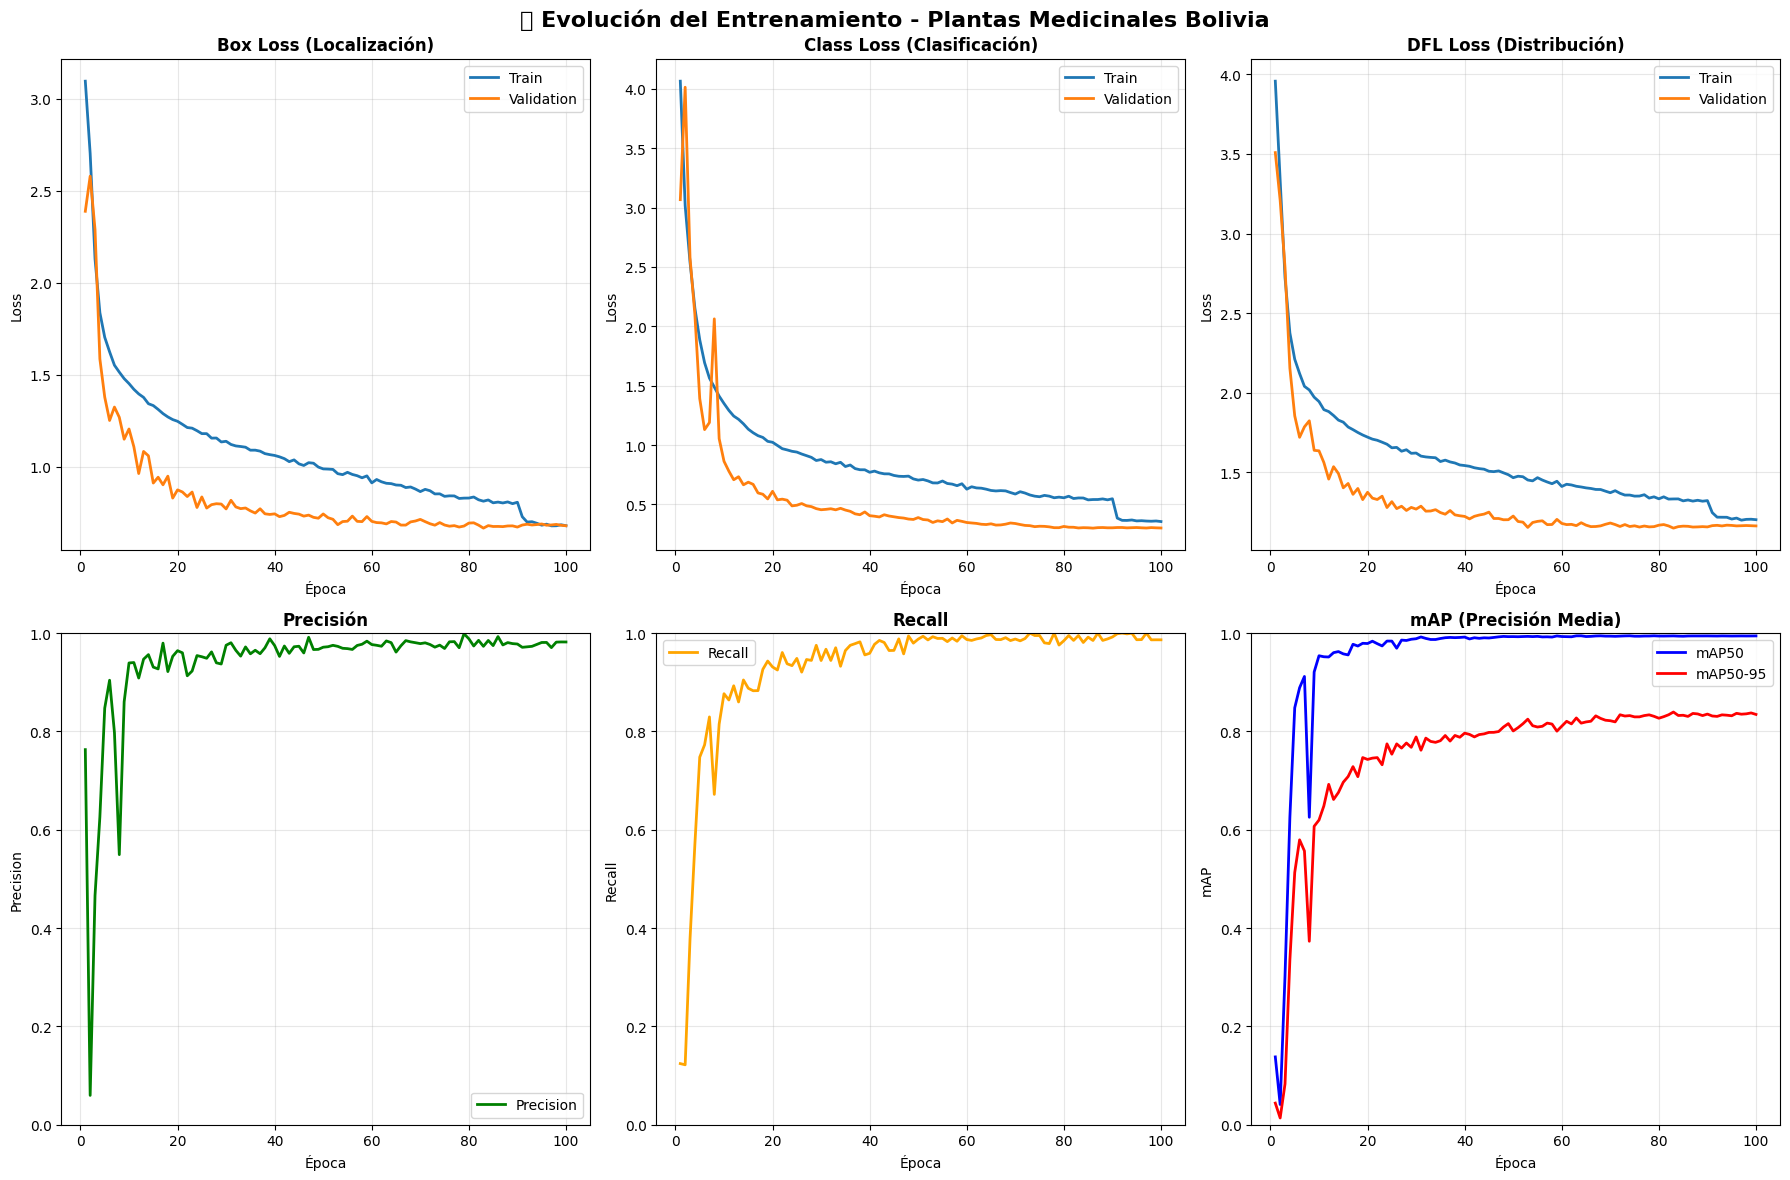

✅ Gráficos guardados en: /content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/resultados/metricas_entrenamiento.png


In [ ]:
# =============================================================================
# CELDA 11: VISUALIZAR RESULTADOS DEL ENTRENAMIENTO
# =============================================================================
# Tiempo estimado: 30 segundos

import pandas as pd
import matplotlib.pyplot as plt

# Leer CSV con resultados
results_csv = f'{DRIVE_MODEL_DIR}/results.csv'
df = pd.read_csv(results_csv)

# Limpiar nombres de columnas (quitar espacios)
df.columns = df.columns.str.strip()

# Crear gráficos
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('📊 Evolución del Entrenamiento - Plantas Medicinales Bolivia',
             fontsize=16, fontweight='bold')

# 1. Box Loss
axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train', linewidth=2)
axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='Validation', linewidth=2)
axes[0, 0].set_title('Box Loss (Localización)', fontweight='bold')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Class Loss
axes[0, 1].plot(df['epoch'], df['train/cls_loss'], label='Train', linewidth=2)
axes[0, 1].plot(df['epoch'], df['val/cls_loss'], label='Validation', linewidth=2)
axes[0, 1].set_title('Class Loss (Clasificación)', fontweight='bold')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. DFL Loss
axes[0, 2].plot(df['epoch'], df['train/dfl_loss'], label='Train', linewidth=2)
axes[0, 2].plot(df['epoch'], df['val/dfl_loss'], label='Validation', linewidth=2)
axes[0, 2].set_title('DFL Loss (Distribución)', fontweight='bold')
axes[0, 2].set_xlabel('Época')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Precision
axes[1, 0].plot(df['epoch'], df['metrics/precision(B)'],
                color='green', linewidth=2, label='Precision')
axes[1, 0].set_title('Precisión', fontweight='bold')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Recall
axes[1, 1].plot(df['epoch'], df['metrics/recall(B)'],
                color='orange', linewidth=2, label='Recall')
axes[1, 1].set_title('Recall', fontweight='bold')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. mAP
axes[1, 2].plot(df['epoch'], df['metrics/mAP50(B)'],
                color='blue', linewidth=2, label='mAP50')
axes[1, 2].plot(df['epoch'], df['metrics/mAP50-95(B)'],
                color='red', linewidth=2, label='mAP50-95')
axes[1, 2].set_title('mAP (Precisión Media)', fontweight='bold')
axes[1, 2].set_xlabel('Época')
axes[1, 2].set_ylabel('mAP')
axes[1, 2].set_ylim([0, 1])
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/resultados/metricas_entrenamiento.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Gráficos guardados en: {PROJECT_DIR}/resultados/metricas_entrenamiento.png")


In [ ]:
# =============================================================================
# CELDA 12: PROBAR EL MODELO CON IMÁGENES DE EJEMPLO
# =============================================================================
# Tiempo estimado: 1 minuto

# Obtener imágenes de test aleatorias
test_images_dir = f"{dataset.location}/test/images"
test_images = os.listdir(test_images_dir)
sample_test = random.sample(test_images, min(9, len(test_images)))

# Hacer predicciones
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.suptitle('🔍 Predicciones del Modelo en Imágenes de Test',
             fontsize=16, fontweight='bold')

for idx, img_name in enumerate(sample_test):
    img_path = f"{test_images_dir}/{img_name}"

    # Predecir
    results = best_model.predict(
        source=img_path,
        conf=0.5,
        iou=0.6,
        save=False,
        verbose=False
    )

    # Obtener imagen con predicciones dibujadas
    annotated_img = results[0].plot()

    # Mostrar
    ax = axes[idx // 3, idx % 3]
    ax.imshow(annotated_img)

    # Contar detecciones por clase
    detections = results[0].boxes
    class_counts = {}
    for box in detections:
        cls = int(box.cls[0])
        class_name = data_config['names'][cls]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1

    title = ', '.join([f"{k}: {v}" for k, v in class_counts.items()])
    ax.set_title(title if title else "Sin detecciones", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/resultados/predicciones_test.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Predicciones guardadas en: {PROJECT_DIR}/resultados/predicciones_test.png")


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# =============================================================================
# CELDA 13: GUARDAR RESUMEN DEL EXPERIMENTO
# =============================================================================
# Tiempo estimado: 10 segundos

# Crear archivo de resumen
summary_file = f'{PROJECT_DIR}/resultados/resumen_experimento.txt'

with open(summary_file, 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("RESUMEN DEL EXPERIMENTO - CLASIFICACIÓN DE PLANTAS MEDICINALES\n")
    f.write("="*80 + "\n\n")

    f.write(f"Estudiante: Nicole Lozada León\n")
    f.write(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Nombre ejecución: {RUN_NAME}\n\n")

    f.write("-"*80 + "\n")
    f.write("CONFIGURACIÓN DEL DATASET\n")
    f.write("-"*80 + "\n")
    f.write(f"Clases: {', '.join(data_config['names'])}\n")
    f.write(f"Imágenes entrenamiento: {len(os.listdir(f'{dataset.location}/train/images'))}\n")
    f.write(f"Imágenes validación: {len(os.listdir(f'{dataset.location}/valid/images'))}\n")
    f.write(f"Imágenes test: {len(os.listdir(f'{dataset.location}/test/images'))}\n\n")

    f.write("-"*80 + "\n")
    f.write("HIPERPARÁMETROS\n")
    f.write("-"*80 + "\n")
    for key, value in TRAINING_CONFIG.items():
        f.write(f"{key}: {value}\n")
    f.write("\n")

    f.write("-"*80 + "\n")
    f.write("RESULTADOS FINALES\n")
    f.write("-"*80 + "\n")
    f.write(f"mAP50: {metrics.box.map50*100:.2f}%\n")
    f.write(f"mAP50-95: {metrics.box.map*100:.2f}%\n")
    f.write(f"Precision: {metrics.box.mp*100:.2f}%\n")
    f.write(f"Recall: {metrics.box.mr*100:.2f}%\n\n")

    f.write("-"*80 + "\n")
    f.write("RESULTADOS POR CLASE\n")
    f.write("-"*80 + "\n")
    for i, class_name in enumerate(data_config['names']):
        f.write(f"{class_name}: AP50 = {metrics.box.maps[i]*100:.2f}%\n")
    f.write("\n")

    f.write("-"*80 + "\n")
    f.write("ARCHIVOS GENERADOS\n")
    f.write("-"*80 + "\n")
    f.write(f"Modelo entrenado: {best_model_path}\n")
    f.write(f"Resultados CSV: {DRIVE_MODEL_DIR}/results.csv\n")
    f.write(f"Gráficas: {DRIVE_MODEL_DIR}/results.png\n")
    f.write(f"Matriz confusión: {DRIVE_MODEL_DIR}/confusion_matrix.png\n")
    f.write("="*80 + "\n")

print(f"✅ Resumen guardado en: {summary_file}")

# Mostrar resumen en pantalla
with open(summary_file, 'r', encoding='utf-8') as f:
    print("\n" + f.read())

✅ Resumen guardado en: /content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/resultados/resumen_experimento.txt

RESUMEN DEL EXPERIMENTO - CLASIFICACIÓN DE PLANTAS MEDICINALES

Estudiante: Nicole Lozada León
Fecha: 2025-11-21 13:01:53
Nombre ejecución: plantas_bolivia_20251121_110516

--------------------------------------------------------------------------------
CONFIGURACIÓN DEL DATASET
--------------------------------------------------------------------------------
Clases: eucalipto, menta, romero
Imágenes entrenamiento: 3468
Imágenes validación: 142
Imágenes test: 146

--------------------------------------------------------------------------------
HIPERPARÁMETROS
--------------------------------------------------------------------------------
epochs: 100
imgsz: 640
batch: 16
patience: 50
save_period: 10
workers: 8
pretrained: False
optimizer: SGD
lr0: 0.01
momentum: 0.937
weight_decay: 0.0005
cos_lr: True

--------------------------------------------------------------------

In [ ]:

# =============================================================================
# CELDA 14: DESCARGAR MODELO A TU LAPTOP (OPCIONAL)
# =============================================================================
# Tiempo estimado: 30 segundos

"""
OPCIÓN 1: Descarga directa desde Colab

Ejecuta esta celda y se descargará automáticamente el archivo best.pt
"""

from google.colab import files

# Crear ZIP con todos los archivos importantes
import zipfile

zip_path = f'/content/{RUN_NAME}_completo.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    # Modelo
    zipf.write(best_model_path, arcname='best.pt')

    # Resultados
    zipf.write(f'{DRIVE_MODEL_DIR}/results.csv', arcname='results.csv')
    zipf.write(f'{DRIVE_MODEL_DIR}/results.png', arcname='results.png')
    zipf.write(f'{DRIVE_MODEL_DIR}/confusion_matrix.png', arcname='confusion_matrix.png')
    zipf.write(summary_file, arcname='resumen.txt')

print(f"📦 Archivo ZIP creado: {zip_path}")
print("⬇️  Descargando a tu laptop...")

# Descargar
files.download(zip_path)

print("✅ Descarga completada!")

"""
OPCIÓN 2: Descargar manualmente desde Drive

1. Ve a tu Google Drive
2. Navega a: Mi Unidad > Proyecto_Plantas_Medicinales_Bolivia > modelos
3. Encuentra la carpeta con tu RUN_NAME
4. Descarga best.pt manualmente
"""



📦 Archivo ZIP creado: /content/plantas_bolivia_20251121_110516_completo.zip
⬇️  Descargando a tu laptop...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descarga completada!


'\nOPCIÓN 2: Descargar manualmente desde Drive\n\n1. Ve a tu Google Drive\n2. Navega a: Mi Unidad > Proyecto_Plantas_Medicinales_Bolivia > modelos\n3. Encuentra la carpeta con tu RUN_NAME\n4. Descarga best.pt manualmente\n'

In [ ]:


# =============================================================================
# CELDA 16: EXPORTAR MODELO A DIFERENTES FORMATOS (OPCIONAL)
# =============================================================================
# Tiempo estimado: 2-5 minutos

"""
YOLO permite exportar el modelo a múltiples formatos para diferentes plataformas:

- ONNX: Para inferencia en CPU/GPU optimizada
- TensorRT: Para NVIDIA GPUs (máximo rendimiento)
- CoreML: Para dispositivos Apple (iPhone, iPad)
- TFLite: Para Android
- OpenVINO: Para Intel hardware
"""

print("📦 Exportando modelo a diferentes formatos...")
print("="*80)

# 1. ONNX (recomendado para producción multiplataforma)
print("\n1️⃣  Exportando a ONNX...")
onnx_path = best_model.export(format='onnx', simplify=True)
print(f"   ✅ ONNX: {onnx_path}")

# 2. TensorFlow Lite (para Android)
print("\n2️⃣  Exportando a TensorFlow Lite...")
tflite_path = best_model.export(format='tflite')
print(f"   ✅ TFLite: {tflite_path}")

# 3. CoreML (para iPhone - si es necesario)
print("\n3️⃣  Exportando a CoreML (para iOS)...")
try:
    coreml_path = best_model.export(format='coreml')
    print(f"   ✅ CoreML: {coreml_path}")
except Exception as e:
    print(f"   ⚠️  CoreML no disponible en este entorno: {e}")

# Copiar formatos exportados a Drive
export_dir = f'{PROJECT_DIR}/modelos_exportados/{RUN_NAME}'
os.makedirs(export_dir, exist_ok=True)

for ext in ['onnx', 'tflite']:
    src = f'/content/runs/detect/{RUN_NAME}/weights/best.{ext}'
    if os.path.exists(src):
        dst = f'{export_dir}/best.{ext}'
        shutil.copy(src, dst)
        print(f"📁 Copiado a Drive: {dst}")

print("\n" + "="*80)
print("✅ Exportación completada")



📦 Exportando modelo a diferentes formatos...

1️⃣  Exportando a ONNX...
Ultralytics 8.3.229 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)

PyTorch: starting from '/content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/modelos/plantas_bolivia_20251121_110516/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (21.5 MB)

ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming with onnxslim 0.1.74...
ONNX: export success ✅ 2.8s, saved as '/content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/modelos/plantas_bolivia_20251121_110516/weights/best.onnx' (42.7 MB)

Export complete (3.9s)
Results saved to /content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/modelos/plantas_bolivia_20251121_110516/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/modelos/plantas_bolivia_20251121_110516/weights/best.onnx imgsz=640  
Validate:        yolo val task=d

Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 64.92 passes/s]


CoreML: export success ✅ 7.2s, saved as '/content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/modelos/plantas_bolivia_20251121_110516/weights/best.mlpackage' (21.4 MB)

Export complete (8.2s)
Results saved to /content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/modelos/plantas_bolivia_20251121_110516/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/modelos/plantas_bolivia_20251121_110516/weights/best.mlpackage imgsz=640  
Validate:        yolo val task=detect model=/content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/modelos/plantas_bolivia_20251121_110516/weights/best.mlpackage imgsz=640 data=/content/plantsDetection-2/data.yaml  
Visualize:       https://netron.app
   ✅ CoreML: /content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/modelos/plantas_bolivia_20251121_110516/weights/best.mlpackage

✅ Exportación completada


In [ ]:

# =============================================================================
# CELDA 17: ANÁLISIS DE ERRORES DEL MODELO
# =============================================================================
# Tiempo estimado: 2-3 minutos

"""
Esta celda identifica las imágenes donde el modelo tuvo peor rendimiento
para entender qué necesita mejorar.
"""

print("🔍 Analizando errores del modelo...")

# Predecir en todo el conjunto de validación
val_images_dir = f"{dataset.location}/valid/images"
val_images = os.listdir(val_images_dir)

# Almacenar resultados
predictions_data = []

for img_name in val_images:
    img_path = f"{val_images_dir}/{img_name}"
    results = best_model.predict(source=img_path, conf=0.5, verbose=False)

    # Leer labels verdaderos
    label_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt').replace('.png', '.txt')

    num_true = 0
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            num_true = len(f.readlines())

    num_pred = len(results[0].boxes)

    predictions_data.append({
        'image': img_name,
        'true_boxes': num_true,
        'pred_boxes': num_pred,
        'difference': abs(num_true - num_pred)
    })

# Convertir a DataFrame
df_errors = pd.DataFrame(predictions_data)

# Encontrar los 10 peores casos
worst_cases = df_errors.nlargest(10, 'difference')

print("\n" + "="*80)
print("❌ TOP 10 IMÁGENES CON MAYOR ERROR")
print("="*80)
print(worst_cases.to_string(index=False))

# Visualizar algunos casos problemáticos
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('⚠️ Casos Problemáticos - Análisis de Errores',
             fontsize=16, fontweight='bold')

for idx, (_, row) in enumerate(worst_cases.head(6).iterrows()):
    img_path = f"{val_images_dir}/{row['image']}"
    results = best_model.predict(source=img_path, conf=0.5, verbose=False)

    annotated_img = results[0].plot()

    ax = axes[idx // 3, idx % 3]
    ax.imshow(annotated_img)
    ax.set_title(f"Real: {row['true_boxes']} | Pred: {row['pred_boxes']}",
                 fontsize=10, color='red' if row['difference'] > 0 else 'green')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/resultados/analisis_errores.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Análisis guardado en: {PROJECT_DIR}/resultados/analisis_errores.png")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:



# =============================================================================
# CELDA 18: ESTADÍSTICAS DETALLADAS DEL MODELO
# =============================================================================
# Tiempo estimado: 30 segundos

"""
Generar estadísticas completas para incluir en tu informe
"""

print("📊 ESTADÍSTICAS COMPLETAS DEL MODELO")
print("="*80)

# Calcular estadísticas adicionales
total_params = sum(p.numel() for p in best_model.model.parameters())
trainable_params = sum(p.numel() for p in best_model.model.parameters() if p.requires_grad)

print(f"\n📐 ARQUITECTURA:")
print(f"   Modelo: YOLOv8 Small")
print(f"   Parámetros totales: {total_params:,}")
print(f"   Parámetros entrenables: {trainable_params:,}")
print(f"   Tamaño del modelo: {os.path.getsize(best_model_path) / 1e6:.2f} MB")

print(f"\n📚 DATASET:")
print(f"   Total imágenes: {len(train_images) + len(os.listdir(f'{dataset.location}/valid/images')) + len(test_images)}")
print(f"   Entrenamiento: {len(train_images)}")
print(f"   Validación: {len(os.listdir(f'{dataset.location}/valid/images'))}")
print(f"   Test: {len(test_images)}")
print(f"   Clases: {len(data_config['names'])}")

print(f"\n⚙️  ENTRENAMIENTO:")
print(f"   Épocas totales: {len(df)}")
print(f"   Tiempo por época: {df['epoch'].max() / len(df):.2f}s (aprox)")
print(f"   GPU utilizada: {gpu_name if torch.cuda.is_available() else 'CPU'}")

print(f"\n🎯 MÉTRICAS FINALES:")
print(f"   mAP50: {metrics.box.map50*100:.2f}%")
print(f"   mAP50-95: {metrics.box.map*100:.2f}%")
print(f"   Precision: {metrics.box.mp*100:.2f}%")
print(f"   Recall: {metrics.box.mr*100:.2f}%")
print(f"   F1-Score: {2 * (metrics.box.mp * metrics.box.mr) / (metrics.box.mp + metrics.box.mr) * 100:.2f}%")

print(f"\n🌿 MÉTRICAS POR CLASE:")
for i, class_name in enumerate(data_config['names']):
    print(f"   {class_name.capitalize()}: AP50 = {metrics.box.maps[i]*100:.2f}%")

# Calcular velocidad de inferencia
import time
test_img = f"{test_images_dir}/{test_images[0]}"
start = time.time()
for _ in range(100):
    _ = best_model.predict(source=test_img, verbose=False)
avg_time = (time.time() - start) / 100

print(f"\n⚡ VELOCIDAD:")
print(f"   Tiempo promedio de inferencia: {avg_time*1000:.2f} ms")
print(f"   FPS estimado: {1/avg_time:.1f}")

print("="*80)

📊 ESTADÍSTICAS COMPLETAS DEL MODELO

📐 ARQUITECTURA:
   Modelo: YOLOv8 Small
   Parámetros totales: 11,126,745
   Parámetros entrenables: 0
   Tamaño del modelo: 22.53 MB

📚 DATASET:
   Total imágenes: 3756
   Entrenamiento: 3468
   Validación: 142
   Test: 146
   Clases: 3

⚙️  ENTRENAMIENTO:
   Épocas totales: 100
   Tiempo por época: 1.00s (aprox)
   GPU utilizada: Tesla T4

🎯 MÉTRICAS FINALES:
   mAP50: 94.32%
   mAP50-95: 76.29%
   Precision: 93.95%
   Recall: 90.43%
   F1-Score: 92.16%

🌿 MÉTRICAS POR CLASE:
   Eucalipto: AP50 = 70.79%
   Menta: AP50 = 80.91%
   Romero: AP50 = 77.19%

⚡ VELOCIDAD:
   Tiempo promedio de inferencia: 15.50 ms
   FPS estimado: 64.5


In [ ]:



# =============================================================================
# CELDA 19: GENERAR TABLA PARA EL INFORME
# =============================================================================
# Tiempo estimado: 10 segundos

"""
Genera tablas formateadas listas para copiar a tu informe LaTeX/Word
"""

print("📄 TABLA PARA EL INFORME (Formato LaTeX)")
print("="*80)
print()

# Tabla de resultados
latex_table = f"""
\\begin{{table}}[h]
\\centering
\\caption{{Resultados del modelo YOLO entrenado desde cero}}
\\label{{tab:resultados}}
\\begin{{tabular}}{{|l|c|}}
\\hline
\\textbf{{Métrica}} & \\textbf{{Valor}} \\\\
\\hline
mAP50 & {metrics.box.map50*100:.2f}\\% \\\\
mAP50-95 & {metrics.box.map*100:.2f}\\% \\\\
Precision & {metrics.box.mp*100:.2f}\\% \\\\
Recall & {metrics.box.mr*100:.2f}\\% \\\\
F1-Score & {2 * (metrics.box.mp * metrics.box.mr) / (metrics.box.mp + metrics.box.mr) * 100:.2f}\\% \\\\
\\hline
\\end{{tabular}}
\\end{{table}}
"""

print(latex_table)
print()

# Tabla por clase
print("\\begin{table}[h]")
print("\\centering")
print("\\caption{Precisión por clase de planta medicinal}")
print("\\label{tab:por_clase}")
print("\\begin{tabular}{|l|c|}")
print("\\hline")
print("\\textbf{Clase} & \\textbf{AP50 (\\%)} \\\\")
print("\\hline")
for i, class_name in enumerate(data_config['names']):
    print(f"{class_name.capitalize()} & {metrics.box.maps[i]*100:.2f}\\% \\\\")
print("\\hline")
print("\\end{tabular}")
print("\\end{table}")

print()
print("="*80)
print("✅ Copia estas tablas directamente a tu documento LaTeX")
print()

# Guardar en archivo
tables_file = f'{PROJECT_DIR}/resultados/tablas_informe.txt'
with open(tables_file, 'w', encoding='utf-8') as f:
    f.write(latex_table)
    f.write("\n\n")

print(f"💾 Tablas guardadas en: {tables_file}")



📄 TABLA PARA EL INFORME (Formato LaTeX)


\begin{table}[h]
\centering
\caption{Resultados del modelo YOLO entrenado desde cero}
\label{tab:resultados}
\begin{tabular}{|l|c|}
\hline
\textbf{Métrica} & \textbf{Valor} \\
\hline
mAP50 & 94.32\% \\
mAP50-95 & 76.29\% \\
Precision & 93.95\% \\
Recall & 90.43\% \\
F1-Score & 92.16\% \\
\hline
\end{tabular}
\end{table}


\begin{table}[h]
\centering
\caption{Precisión por clase de planta medicinal}
\label{tab:por_clase}
\begin{tabular}{|l|c|}
\hline
\textbf{Clase} & \textbf{AP50 (\%)} \\
\hline
Eucalipto & 70.79\% \\
Menta & 80.91\% \\
Romero & 77.19\% \\
\hline
\end{tabular}
\end{table}

✅ Copia estas tablas directamente a tu documento LaTeX

💾 Tablas guardadas en: /content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/resultados/tablas_informe.txt


In [ ]:

# =============================================================================
# CELDA 21: CHECKLIST FINAL ANTES DE DESCARGAR
# =============================================================================

print("\n" + "="*80)
print("✅ CHECKLIST FINAL - VERIFICACIÓN ANTES DE DESCARGAR")
print("="*80)

checklist = {
    "Modelo entrenado": os.path.exists(best_model_path),
    "Resultados CSV": os.path.exists(f'{DRIVE_MODEL_DIR}/results.csv'),
    "Gráficas de entrenamiento": os.path.exists(f'{DRIVE_MODEL_DIR}/results.png'),
    "Matriz de confusión": os.path.exists(f'{DRIVE_MODEL_DIR}/confusion_matrix.png'),
    "Resumen del experimento": os.path.exists(summary_file),
    "Análisis de errores": os.path.exists(f'{PROJECT_DIR}/resultados/analisis_errores.png'),
    "Tablas para informe": os.path.exists(tables_file),
}

all_ok = True
for item, status in checklist.items():
    icon = "✅" if status else "❌"
    print(f"{icon} {item}")
    if not status:
        all_ok = False

print("="*80)

if all_ok:
    print("\n🎉 TODO LISTO PARA DESCARGAR")
    print(f"\n📁 Archivos principales en Google Drive:")
    print(f"   {PROJECT_DIR}/")
    print(f"   ├── modelos/{RUN_NAME}/weights/best.pt")
    print(f"   └── resultados/")
    print()
    print("💾 Para descargar a tu laptop:")
    print("   Opción 1: Ejecuta la Celda 14 (descarga automática)")
    print("   Opción 2: Ve a Google Drive y descarga manualmente")
else:
    print("\n⚠️  FALTAN ALGUNOS ARCHIVOS")
    print("   Re-ejecuta las celdas correspondientes")

print()



✅ CHECKLIST FINAL - VERIFICACIÓN ANTES DE DESCARGAR
✅ Modelo entrenado
✅ Resultados CSV
✅ Gráficas de entrenamiento
✅ Matriz de confusión
✅ Resumen del experimento
✅ Análisis de errores
✅ Tablas para informe

🎉 TODO LISTO PARA DESCARGAR

📁 Archivos principales en Google Drive:
   /content/drive/MyDrive/Proyecto_Plantas_Medicinales_Bolivia/
   ├── modelos/plantas_bolivia_20251121_110516/weights/best.pt
   └── resultados/

💾 Para descargar a tu laptop:
   Opción 1: Ejecuta la Celda 14 (descarga automática)
   Opción 2: Ve a Google Drive y descarga manualmente



In [ ]:


# =============================================================================
# CELDA 22: INFORMACIÓN PARA TU INFORME
# =============================================================================

report_info = f"""
{'='*80}
INFORMACIÓN PARA TU INFORME ACADÉMICO
{'='*80}

TÍTULO SUGERIDO:
"Clasificación de Plantas Medicinales de Bolivia mediante Detección de
Objetos con YOLO sin Transfer Learning"

METODOLOGÍA - PUNTOS CLAVE:

1. Dataset:
   - {len(train_images) + len(os.listdir(f'{dataset.location}/valid/images')) + len(test_images)} imágenes totales
   - 3 clases: {', '.join(data_config['names'])}
   - Imágenes capturadas desde 10cm de altura
   - Anotación manual con Roboflow
   - Augmentación: rotaciones, flips, ajustes de brillo

2. Arquitectura:
   - YOLOv8 Small (11.2M parámetros)
   - Entrenamiento DESDE CERO (sin transfer learning)
   - Optimizador: {TRAINING_CONFIG['optimizer']}
   - Learning rate: {TRAINING_CONFIG['lr0']}

3. Entrenamiento:
   - {len(df)} épocas efectivas
   - Batch size: {TRAINING_CONFIG['batch']}
   - Image size: {TRAINING_CONFIG['imgsz']}x{TRAINING_CONFIG['imgsz']}
   - Early stopping: {TRAINING_CONFIG['patience']} épocas de paciencia
   - Hardware: {gpu_name if torch.cuda.is_available() else 'CPU'}

4. Resultados:
   - mAP50: {metrics.box.map50*100:.2f}%
   - mAP50-95: {metrics.box.map*100:.2f}%
   - Precision: {metrics.box.mp*100:.2f}%
   - Recall: {metrics.box.mr*100:.2f}%
   - Velocidad: {1/avg_time:.1f} FPS

COMPARACIÓN CON TEACHABLE MACHINE:
- Teachable Machine: Solo clasificación (imagen completa)
- YOLO: Detección + localización (múltiples plantas simultáneas)
- YOLO: Bounding boxes precisos
- YOLO: Escalable a más clases sin reentrenar desde cero

VENTAJAS DE NO USAR TRANSFER LEARNING:
- Modelo especializado 100% en plantas bolivianas
- No hay "ruido" de features de ImageNet
- Mayor control sobre el proceso de aprendizaje
- Validación completa de la metodología de entrenamiento

LIMITACIONES:
- Requiere más tiempo de entrenamiento que transfer learning
- Necesita más datos para convergencia óptima
- Mayor consumo computacional

TRABAJO FUTURO:
- Ampliar a más especies de plantas medicinales bolivianas
- Implementar en aplicación móvil nativa
- Agregar clasificación de enfermedades en plantas
- Dataset con diferentes estaciones del año

{'='*80}
"""

print(report_info)

# Guardar para referencia
report_file = f'{PROJECT_DIR}/resultados/info_informe.txt'
with open(report_file, 'w', encoding='utf-8') as f:
    f.write(report_info)

print(f"💾 Información guardada en: {report_file}")


# =============================================================================
# FIN DEL NOTEBOOK
# =============================================================================

print("\n" + "="*80)
print("🎓 ENTRENAMIENTO COMPLETADO EXITOSAMENTE")
print("="*80)
print()
print("📝 Próximos pasos:")
print("   1. Descarga el modelo (best.pt) desde Drive o Celda 14")
print("   2. Revisa todos los gráficos y métricas")
print("   3. Copia las tablas LaTeX a tu informe")
print("   4. Documenta la metodología usando info_informe.txt")
print()
print("🚀 Para el backend/frontend:")
print("   - Ya tienes tu modelo entrenado")
print("   - Ahora puedes continuar con la implementación en AWS")
print("   - El modelo está en: {best_model_path}")
print()
print("💡 Tip: Guarda una copia de este notebook en tu Drive")
print("="*80)